In [1]:
import pandas as pd
import numpy as np
from mysqldatabase import *
from sklearn.impute import KNNImputer

In [2]:
dbo = Database()
mobiles = dbo.import_table('mobiles_uncleaned')
dbo.close()

In [3]:
mobiles.head()

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,other
0,Samsung Galaxy S24 FE 5G,34999,84.0,4.00,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Exynos 2400e, Deca Core, 3.11 GHz Processor","8 GB RAM, 128 GB inbuilt",4700 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 8 MP Triple Rear & 10 MP Front...,Memory Card Not Supported,Android v14,NaN,https://cdn1.smartprix.com/rx-iuMmr0OHo-w280-h...,NaN
1,Samsung Galaxy S24 Ultra,84949,92.0,4.35,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.8 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP Quad Rear & 12 MP Front Camera,Memory Card Not Supported,Android v14,NaN,https://cdn1.smartprix.com/rx-iz5ZKOGY0-w280-h...,NaN
2,Samsung Galaxy S25 Edge,109999,89.0,4.45,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8Elite, Octa Core, 4.47 GHz Processor","12 GB RAM, 256 GB inbuilt",3900 mAh Battery with 25W Fast Charging,"6.7 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP + 12 MP Dual Rear & 12 MP Front Camera,NaN,Android v15,No FM Radio,https://cdn1.smartprix.com/rx-iTIjHjVfg-w280-h...,NaN
3,Samsung Galaxy M36 5G,19990,82.0,4.55,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Exynos 1380, Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 25W Fast Charging,"6.74 inches, 1080 x 2340 px, 120 Hz Display wi...",50 MP + 12 MP + 5 MP Triple Rear & 16 MP Front...,"Memory Card (Hybrid), upto 1 TB",Android v15,NaN,https://cdn1.smartprix.com/rx-i2WUf3VQ1-w280-h...,NaN
4,Samsung Galaxy M06 5G,7999,72.0,4.00,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 6300, Octa Core, 2.4 GHz Processor","4 GB RAM, 128 GB inbuilt",5000 mAh Battery with 25W Fast Charging,"6.74 inches, 720 x 1600 px, 90 Hz Display with...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 1.5 TB",Android v15,NaN,https://cdn1.smartprix.com/rx-igMrWL1OC-w280-h...,NaN


In [4]:
mobiles.duplicated('name').sum()

318

In [5]:
mobiles.duplicated(subset=('name','price')).sum()

295

## 🔍 Data Quality Assessment

### 🧼 Dirty Data Issues

#### 📌 Completeness
- Fix **Missing values**

- **Unnecessary rows**:
  - Drop keypad phones (they are not smartphones).

---

#### 📌 Validity
- Fix **Incorrect data types**
  
- **Duplicate rows**:
  - Found **295 duplicates** based on the subset: `("name", "price")`

- **Special handling**:
  - For `"Lenovo Tab M10 FHD Plus 2nd Gen Tablet (Wi-Fi + 128GB)"`, compute the **average price** across its duplicate rows.

---

#### 📌 Accuracy
- *(Currently no issues explicitly mentioned)*

---

#### 📌 Consistency
- Inconsistent value formats found in multiple columns
  
---

### 🧹 Messy Data Issues

- Most of the columns require cleaning, parsing, or restructuring for better analysis

- **Drop column**:
  - `fm_radio` (uninformative)
  - `other` (null)

- **Column reordering**:
  - Rearrange columns for logical flow and readability.

---

### 📊 Price Column Cleanup

- **Change data type** of `price` to numeric.
- **Outlier detection**:
  - Use `df["price"].describe()` for statistical summary.
  - Visualize with boxplots and/or KDE plots.



In [6]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11786 entries, 0 to 11785
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          11786 non-null  object 
 1   price         11786 non-null  object 
 2   spec_score    11778 non-null  float64
 3   user_rating   11766 non-null  float64
 4   connectivity  11775 non-null  object 
 5   cpu           9629 non-null   object 
 6   ram           10525 non-null  object 
 7   battery       11648 non-null  object 
 8   display       11770 non-null  object 
 9   camera        11766 non-null  object 
 10  expandable    10016 non-null  object 
 11  os            8823 non-null   object 
 12  fm_radio      1557 non-null   object 
 13  img           11786 non-null  object 
 14  other         1 non-null      object 
dtypes: float64(2), object(13)
memory usage: 1.3+ MB


In [7]:
mobiles.drop(['other','fm_radio'],axis = 1,inplace=True)

In [8]:
# investigating the duplicated rows issue.

name_price_mask = mobiles.duplicated(subset=("name", "price"))
name_mask = mobiles.duplicated(subset=("name"))

diff_df = mobiles[name_mask].merge(
    mobiles[name_price_mask],
    how="outer",
    indicator=True
)

result = diff_df[diff_df["_merge"] == "left_only"].drop(columns="_merge")
result

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,img
2,Realme 12 Pro 5G (12GB RAM + 256GB),22999,81.0,4.10,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 6 Gen1, Octa Core, 2.2 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 67W Fast Charging,"6.7 inches, 1080 x 2412 px, 120 Hz Display wit...",50 MP + 32 MP + 8 MP Triple Rear & 16 MP Front...,NaN,Android v14,https://cdn1.smartprix.com/rx-iqDKgfAiw-w280-h...
7,Realme 8i,9590,73.0,3.95,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi","Helio G96, Octa Core, 2.05 GHz Processor","4 GB RAM, 64 GB inbuilt",5000 mAh Battery with 18W Fast Charging,"6.6 inches, 1080 x 2412 px, 120 Hz Display wit...",50 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card Supported, upto 256 GB",Android v11,https://cdn1.smartprix.com/rx-iALTIcaCV-w280-h...
14,Realme Narzo 70 5G,13628,78.0,4.00,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 7050, Octa Core, 2.6 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v14,https://cdn1.smartprix.com/rx-iNFfLsvYD-w280-h...
15,Realme Narzo 60 Pro 5G,20416,80.0,4.40,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 7050, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 67W Fast Charging,"6.7 inches, 1080 x 2412 px, 120 Hz Display wit...",100 MP + 2 MP Dual Rear & 16 MP Front Camera,NaN,Android v13,https://cdn1.smartprix.com/rx-iNlT9UoMT-w280-h...
16,Realme 9i 5G (6GB RAM + 128GB),16999,76.0,4.65,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 810 5G, Octa Core, 2.4 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 18W Fast Charging,"6.6 inches, 1080 x 2408 px, 90 Hz Display with...",50 MP + 2 MP + 2 MP Triple Rear & 8 MP Front C...,"Memory Card Supported, upto 1 TB",Android v12,https://cdn1.smartprix.com/rx-iyYgdqwAw-w280-h...
17,OnePlus Nord CE 2 Lite 5G (8GB RAM + 128GB),21849,82.0,4.30,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 695, Octa Core, 2.2 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 33W Fast Charging,"6.59 inches, 1080 x 2412 px, 120 Hz Display wi...",64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,https://cdn1.smartprix.com/rx-igjlSYJeV-w280-h...
22,Oppo A78 4G,13398,79.0,4.25,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi, NFC","Snapdragon 680, Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 67W Fast Charging,"6.43 inches, 1080 x 2400 px, 90 Hz Display wit...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,https://cdn1.smartprix.com/rx-ionT1r0Z0-w280-h...
71,Xiaomi Redmi Note 11 Pro Plus 5G,17999,81.0,4.15,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 695, Octa Core, 2.2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 67W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,"Memory Card (Hybrid), upto 1 TB",Android v11,https://cdn1.smartprix.com/rx-iATlwXeDC-w280-h...
73,Xiaomi Mi 11 Lite NE 5G,23999,81.0,4.30,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 778G , Octa Core, 2.4 GHz Processor","6 GB RAM, 128 GB inbuilt",4250 mAh Battery with 33W Fast Charging,"6.55 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP + 8 MP + 5 MP Triple Rear & 20 MP Front ...,Memory Card (Hybrid),Android v11,https://cdn1.smartprix.com/rx-ieLXKpqf2-w280-h...
76,Xiaomi Redmi Go,4799,45.0,4.15,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi","Snapdragon MSM8917, Quad Core, 1.4 GHz Processor","1 GB RAM, 8 GB inbuilt",3000 mAh Battery,"5 inches, 720 x 1280 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v8.1 (Oreo),https://cdn1.smartprix.com/rx-iN8ugsHzT-w280-h...


In [9]:
mobiles['price'] = mobiles['price'].astype(np.int32)

In [10]:
update_price = result['name'].values
for name in update_price:
    avg = mobiles[mobiles['name'] == name].iloc[:,1].mean()
    idx = mobiles[mobiles['name'] == name].index[0]
    mobiles.loc[idx, 'price'] = avg

C:\Users\ST\AppData\Local\Temp\ipykernel_8288\921914588.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '14806.5' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  mobiles.loc[idx, 'price'] = avg


In [11]:
mobiles.drop_duplicates(subset=('name'), inplace=True)

In [12]:
mobiles.duplicated(subset=('name','price')).sum()

0

In [13]:
mobiles.duplicated().sum()

0

In [14]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11468 entries, 0 to 11785
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          11468 non-null  object 
 1   price         11468 non-null  float64
 2   spec_score    11460 non-null  float64
 3   user_rating   11449 non-null  float64
 4   connectivity  11457 non-null  object 
 5   cpu           9363 non-null   object 
 6   ram           10236 non-null  object 
 7   battery       11330 non-null  object 
 8   display       11452 non-null  object 
 9   camera        11448 non-null  object 
 10  expandable    9746 non-null   object 
 11  os            8591 non-null   object 
 12  img           11468 non-null  object 
dtypes: float64(3), object(10)
memory usage: 1.2+ MB


In [15]:
mobiles.dropna(subset=['connectivity', 'cpu', 'ram','battery', 'display', 'camera'], how='all').shape

(11460, 13)

In [16]:
mobiles.dropna(subset=['connectivity', 'cpu', 'ram','battery', 'display', 'camera'], how='all', inplace=True)

In [17]:
mobiles.isna().sum()

name               0
price              0
spec_score         0
user_rating       19
connectivity       3
cpu             2097
ram             1224
battery          130
display            8
camera            12
expandable      1714
os              2869
img                0
dtype: int64

In [18]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11460 entries, 0 to 11785
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          11460 non-null  object 
 1   price         11460 non-null  float64
 2   spec_score    11460 non-null  float64
 3   user_rating   11441 non-null  float64
 4   connectivity  11457 non-null  object 
 5   cpu           9363 non-null   object 
 6   ram           10236 non-null  object 
 7   battery       11330 non-null  object 
 8   display       11452 non-null  object 
 9   camera        11448 non-null  object 
 10  expandable    9746 non-null   object 
 11  os            8591 non-null   object 
 12  img           11460 non-null  object 
dtypes: float64(3), object(10)
memory usage: 1.2+ MB


In [19]:
mobiles[mobiles['price'] < 3500].isna().sum()        # I noticed this while scraping that, most of the phones below 3500 were keypad phones.
# these are not useful for our analysis.

name               0
price              0
spec_score         0
user_rating       12
connectivity       2
cpu             1868
ram             1158
battery           54
display            7
camera            12
expandable       436
os              2444
img                0
dtype: int64

In [20]:
mobiles = mobiles[mobiles['price'] > 3500]

In [21]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8374 entries, 0 to 11785
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          8374 non-null   object 
 1   price         8374 non-null   float64
 2   spec_score    8374 non-null   float64
 3   user_rating   8367 non-null   float64
 4   connectivity  8373 non-null   object 
 5   cpu           8147 non-null   object 
 6   ram           8309 non-null   object 
 7   battery       8299 non-null   object 
 8   display       8373 non-null   object 
 9   camera        8374 non-null   object 
 10  expandable    7096 non-null   object 
 11  os            7953 non-null   object 
 12  img           8374 non-null   object 
dtypes: float64(3), object(10)
memory usage: 915.9+ KB


In [22]:
mobiles.isna().sum()

name               0
price              0
spec_score         0
user_rating        7
connectivity       1
cpu              227
ram               65
battery           75
display            1
camera             0
expandable      1278
os               421
img                0
dtype: int64

In [23]:
mobiles['expandable'].value_counts()

expandable
Memory Card Supported, upto 32 GB      1191
Memory Card Not Supported              1050
Memory Card Supported                   864
Memory Card Supported, upto 256 GB      649
Memory Card Supported, upto 1 TB        568
Memory Card Supported, upto 128 GB      466
Memory Card Supported, upto 512 GB      401
Memory Card (Hybrid)                    389
Memory Card (Hybrid), upto 1 TB         357
Memory Card (Hybrid), upto 256 GB       230
Memory Card Supported, upto 64 GB       226
Memory Card (Hybrid), upto 512 GB       127
Memory Card (Hybrid), upto 128 GB       118
Memory Card Supported, upto 16 GB       102
Memory Card Supported, upto 2 TB        100
Memory Card (Hybrid), upto 2 TB          79
Memory Card Supported, upto 8 GB         63
Memory Card Supported, upto 4 GB         26
Memory Card (Hybrid), upto 64 GB         21
Memory Card (Hybrid), upto 400 GB        19
Memory Card (Hybrid), upto 1.5 TB        12
Memory Card Supported, upto 400 GB       12
Memory Card Supported

In [24]:
mobiles[mobiles['expandable'].isna()].sample() # no expandable memory

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,img
3862,Honor 400 Pro,80889.0,91.0,4.65,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 100W Fast Charging,"6.7 inches, 1280 x 2800 px, 120 Hz Display wit...",200 MP + 50 MP + 12 MP Triple Rear & 50 MP + 2...,NaN,Android v15,https://cdn1.smartprix.com/rx-ikM2naxIw-w280-h...


In [25]:
mobiles['expandable'] = mobiles['expandable'].fillna('Memory Card Not Supported')

In [26]:
mobiles.reset_index(drop=True,inplace=True)

In [27]:
imputer = KNNImputer(n_neighbors = 10)
to_impute = mobiles[['price','spec_score','user_rating']]
imputed_df = pd.DataFrame(imputer.fit_transform(to_impute), columns = ['price','spec_score','user_rating'], index = mobiles.index)

mobiles['user_rating'] = imputed_df['user_rating']

In [28]:
mobiles.isna().sum()

name              0
price             0
spec_score        0
user_rating       0
connectivity      1
cpu             227
ram              65
battery          75
display           1
camera            0
expandable        0
os              421
img               0
dtype: int64

In [29]:
mobiles['os'].unique()

array(['Android v14', 'Android v15', 'Android v16', 'Android v13',
       'Android v12', 'Android v10', nan, 'Android v11',
       'Android v9.0 (Pie)', 'Android v10.0', 'Android v8.1 (Oreo)',
       'Android v8.0 (Oreo)', 'Android v7.0 (Nougat)',
       'Android v7.1 (Nougat)', 'Android v7.1.1 (Nougat)',
       'Android v6.0.1 (Marshmallow)', 'Android v5.1.1 (Lollipop)',
       'Android v6.0 (Marshmallow)', 'Android v6 (Marshmallow)',
       'Tizen OS v3.0', 'Android v5.1 (Lollipop)',
       'Android v4.4.2 (KitKat)', 'Android v5.0 (Lollipop)',
       'Android v5.0.2 (Lollipop)', 'Android v4.4.4 (KitKat)',
       'Tizen OS v2.3', 'Android v4.4 (KitKat)',
       'Android v4.3 (Jelly Bean)', 'Android v4.2 (Jelly Bean)',
       'Android v4.2.2 (Jelly Bean)', 'Android v4.1.2 (Jelly Bean)',
       'Android v4.1 (Jelly Bean)', 'Android v4.1.1 (Jelly Bean)',
       'Android v2.3 (Gingerbread)', 'Android v4.0.4 (ICS)',
       'Android v2.3.6 (Gingerbread)', 'Bada v2.0',
       'Android v2.3.5

In [30]:
for column in mobiles.columns:
    if mobiles[column].dtype == 'O':
        mobiles[column] = mobiles[column].str.strip().str.lower().str.replace('\u2009','').str.replace('\u200b','').str.replace('\u200e','').str.replace('\t','')

In [31]:
mobiles['brand'] = mobiles['name'].str.split().str.get(0).str.strip()

In [32]:
mobiles[mobiles['os'].isna()]['brand'].value_counts()

brand
samsung       85
nokia         63
lg            35
micromax      29
huawei        25
motorola      23
spice         16
sony          16
meizu         16
lava          12
doogee         8
blackberry     8
oppo           7
karbonn        7
honor          7
htc            6
xiaomi         5
asus           5
tecno          5
alcatel        5
vivo           5
realme         4
ulefone        4
oneplus        3
nubia          3
ikall          3
gionee         2
light          2
zte            2
hmd            2
acer           2
intex          2
infinix        1
iqoo           1
google         1
tcl            1
Name: count, dtype: int64

In [33]:
mobiles[mobiles['os'].apply(lambda x: (True if 'window' in x else False) if isinstance(x,str) else False)]['brand'].value_counts()

brand
nokia        27
htc          12
samsung       6
acer          3
lg            3
huawei        2
sony          2
micromax      1
panasonic     1
Name: count, dtype: int64

In [34]:
def modify_os(row):
    os = row['os']
    brand = row['brand']
    if not pd.isna(os):
        if 'windows' in os:
            return 'windows'
        elif 'android' in os:
            return 'android'
        elif 'ios' in os:
            return 'ios'
        else:
            return 'other'
    else:
        if brand == 'nokia':
            return 'windows'
        elif brand == 'apple':
            return 'ios'
        else:
            return 'android'

In [35]:
mobiles['os'] = mobiles.apply(modify_os, axis = 1)

In [36]:
mobiles.isna().sum()

name              0
price             0
spec_score        0
user_rating       0
connectivity      1
cpu             227
ram              65
battery          75
display           1
camera            0
expandable        0
os                0
img               0
brand             0
dtype: int64

In [37]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8374 entries, 0 to 8373
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          8374 non-null   object 
 1   price         8374 non-null   float64
 2   spec_score    8374 non-null   float64
 3   user_rating   8374 non-null   float64
 4   connectivity  8373 non-null   object 
 5   cpu           8147 non-null   object 
 6   ram           8309 non-null   object 
 7   battery       8299 non-null   object 
 8   display       8373 non-null   object 
 9   camera        8374 non-null   object 
 10  expandable    8374 non-null   object 
 11  os            8374 non-null   object 
 12  img           8374 non-null   object 
 13  brand         8374 non-null   object 
dtypes: float64(3), object(11)
memory usage: 916.0+ KB


In [38]:
mobiles.describe()

,price,spec_score,user_rating
count,8374.000000,8374.000000,8374.000000
mean,22962.239631,64.825412,4.251935
std,25499.285610,18.103346,0.383434
min,3501.000000,5.000000,1.250000
25%,7999.000000,52.000000,4.100000
50%,14990.000000,69.000000,4.300000
75%,26997.000000,80.000000,4.500000
max,480000.000000,98.000000,5.000000


In [39]:
mobiles[mobiles['spec_score'] == 5]

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,img,brand
4211,nokia 3610,7049.0,5.0,2.0,single sim,NaN,NaN,830mah battery,96x65px display,no rear camera,memory card not supported,windows,https://cdn1.smartprix.com/rx-ikqfnouxd-w280-h...,nokia


In [40]:
mobiles.drop([4211],axis = 0,inplace = True)

In [41]:
mobiles[(mobiles['spec_score'] <= 20) & (mobiles['user_rating'] < 3)]

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,img,brand
760,samsung chat 369,5990.0,17.0,2.10,"single sim, 3g",NaN,104mb inbuilt,1000mah battery,"2.2 inches, 320x240px display",2mp rear camera,"memory card supported, upto 16gb",android,https://cdn1.smartprix.com/rx-io8vjakr2-w280-h...,samsung
804,samsung corby s3650,5090.0,17.0,2.65,single sim,NaN,50mb inbuilt,960mah battery,"2.8 inches, 240x320px display",2mp rear camera,memory card supported,android,https://cdn1.smartprix.com/rx-ivgrhaevy-w280-h...,samsung
805,samsung c3630,3750.0,12.0,2.20,single sim,NaN,90mb inbuilt,900mah battery,"2.2 inches, 240x320px display",1.3mp rear camera,memory card not supported,android,https://cdn1.smartprix.com/rx-imr2sgrpl-w280-h...,samsung
808,samsung corby pop c3510,4890.0,17.0,2.90,single sim,NaN,30mb inbuilt,960mah battery,"2.8 inches, 240x320px display",1.3mp rear camera,"memory card supported, upto 8gb",android,https://cdn1.smartprix.com/rx-i00q5g0px-w280-h...,samsung
812,samsung corby tv f339,6000.0,19.0,2.35,"single sim, 3g",NaN,79mb inbuilt,960mah battery,"2.8 inches, 240x320px display",2mp rear camera,"memory card supported, upto 16gb",android,https://cdn1.smartprix.com/rx-ir9amnceu-w280-h...,samsung
816,samsung c3560,4720.0,14.0,2.45,single sim,NaN,50mb inbuilt,800mah battery,"2.2 inches, 240x320px display",2mp rear camera,"memory card supported, upto 16gb",android,https://cdn1.smartprix.com/rx-ixgdvyitb-w280-h...,samsung
829,samsung nx2 f699,5899.0,13.0,2.05,single sim,NaN,17mb inbuilt,960mah battery,"2.2 inches, 176x220px display",1.3mp rear camera,"memory card supported, upto 2gb",android,https://cdn1.smartprix.com/rx-il0859him-w280-h...,samsung
832,samsung metro c3752,4110.0,15.0,2.65,dual sim,NaN,40mb inbuilt,900mah battery,"2.4 inches, 240x320px display",3mp rear camera,"memory card supported, upto 16gb",android,https://cdn1.smartprix.com/rx-ibz69ud21-w280-h...,samsung
2157,motorola gleam,5000.0,15.0,2.15,single sim,NaN,5mb inbuilt,750mah battery,"2.4 inches, 240x320px display",2mp rear camera,"memory card supported, upto 16gb",android,https://cdn1.smartprix.com/rx-ivozopnmm-w280-h...,motorola
2320,motorola zn300,4999.0,15.0,2.30,single sim,NaN,8mb inbuilt,940mah battery,240x320px display,3mp rear camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-i2ywvvgnz-w280-h...,motorola


In [42]:
mobiles[mobiles['connectivity'] == 'dual sim, 3g']

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,img,brand
809,samsung w259 duos,5271.0,17.0,3.75,"dual sim, 3g",NaN,40mb inbuilt,1140mah battery,"2.2 inches, 176x220px display",1.3mp rear camera,"memory card supported, upto 8gb",android,https://cdn1.smartprix.com/rx-ieuxxgfyw-w280-h...,samsung
1939,oppo joy r1001,4990.0,32.0,4.40,"dual sim, 3g","mt6572, dual core, 1.3ghz processor","512mb ram, 4gb inbuilt",1700mah battery,"4 inches, 480x800px display",3mp rear & 0.3mp front camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-ipwyddbsx-w280-h...,oppo
4036,nokia 3310 3g,3799.0,20.0,4.55,"dual sim, 3g",NaN,64mb inbuilt,1200mah battery,"2.4 inches, 240x320px display",2mp rear camera,"memory card supported, upto 32gb",windows,https://cdn1.smartprix.com/rx-i4u38rf6x-w280-h...,nokia
4182,nokia 515 dual sim,12600.0,22.0,4.05,"dual sim, 3g",NaN,"64mb ram, 256mb inbuilt",1200mah battery,"2.4 inches, 240x320px display",5mp rear camera,"memory card supported, upto 32gb",windows,https://cdn1.smartprix.com/rx-ifrvwpw7f-w280-h...,nokia
4473,lava iris 400q,4378.0,36.0,3.15,"dual sim, 3g","quad core, 1.2ghz processor","1gb ram, 4gb inbuilt",1700mah battery,"4 inches, 480x800px display",5mp rear & 0.3mp front camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-iswfvjlri-w280-h...,lava
4479,lava iris 3g 412,3699.0,28.0,4.20,"dual sim, 3g","dual core, 1ghz processor","512mb ram, 512mb inbuilt",1500mah battery,"4 inches, 480x800px display",2mp rear & 0.3mp front camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-ipmnzoosl-w280-h...,lava
5073,micromax gc700,10999.0,21.0,2.10,"dual sim, 3g",NaN,NaN,940mah battery,"2.8 inches, 240x400px display",2mp rear camera,"memory card supported, upto 4gb",android,https://cdn1.smartprix.com/rx-inpefzhob-w280-h...,micromax
6496,spice blueberry aura qt-64,3973.0,17.0,4.30,"dual sim, 3g",NaN,7mb inbuilt,1000mah battery,"2.6 inches, 320x240px display",2mp rear camera,"memory card supported, upto 8gb",android,https://cdn1.smartprix.com/rx-iozawrvfz-w280-h...,spice
7736,alcatel ot-901n,3999.0,19.0,3.25,"dual sim, 3g","mtk6268, single core, 245mhz processor",50mb inbuilt,1000mah battery,"2.4 inches, 240x320px display",2mp rear camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-i5z2eiy2m-w280-h...,alcatel
7963,lg a350,3999.0,17.0,3.45,"dual sim, 3g",NaN,"128mb ram, 59mb inbuilt",950mah battery,"2.2 inches, 176x220px display",1.3mp rear camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-iblwndacj-w280-h...,lg


In [43]:
drop_index = mobiles[mobiles.apply(
    lambda x: (
        True if ('mb' in x['ram']) and (pd.isna(x['cpu'])) else False
    ) if isinstance(x['ram'],str) else False, axis = 1
)].index

In [44]:
mobiles = mobiles.drop(drop_index,axis=0).reset_index(drop = True)

In [45]:
mobiles[(mobiles['spec_score'] < 30) & (mobiles['ram'].apply(lambda x: (True if ('mb' in x) else False) if isinstance(x,str) else False))]

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,img,brand
498,samsung galaxy pocket 2,5000.0,29.0,4.60,"dual sim, 3g, wi-fi","single core, 1ghz processor","512mb ram, 4gb inbuilt",1200mah battery,"3.3 inches, 240x320px display",2mp rear camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-izkiuora8-w280-h...,samsung
515,samsung galaxy star duos s5282,3599.0,26.0,3.80,"dual sim, wi-fi","single core, 1ghz processor","512mb ram, 4gb inbuilt",1200mah battery,"3 inches, 240x320px display",2mp rear camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-ihg4twshn-w280-h...,samsung
530,samsung galaxy y cdma i509,7299.0,24.0,4.00,"single sim, 3g, wi-fi","single core, 600mhz processor",140mb inbuilt,1200mah battery,"3 inches, 320x240px display",2mp rear camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-i5ugd9btk-w280-h...,samsung
531,samsung wave y s5380,6990.0,25.0,4.45,"single sim, 3g, wi-fi, nfc","single core, 832mhz processor",150mb inbuilt,1200mah battery,"3.2 inches, 320x480px display",2mp rear camera,"memory card supported, upto 32gb",other,https://cdn1.smartprix.com/rx-imejqb5zy-w280-h...,samsung
532,samsung galaxy y pro duos b5512,5555.0,25.0,3.95,"dual sim, 3g, wi-fi","single core, 832mhz processor",384mb ram,1350mah battery,"2.6 inches, 320x240px display",3.15mp rear & 0.3mp front camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-ib0xkqmi8-w280-h...,samsung
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8118,intex cloud z5,3999.0,29.0,3.80,"dual sim, wi-fi","dual core, 1ghz processor","512mb ram, 107mb inbuilt",2100mah battery,"5 inches, 480x800px display",5mp rear & 1.3mp front camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-iwgawgo3d-w280-h...,intex
8119,intex aqua sx,3930.0,24.0,4.50,"dual sim, wi-fi","single core, 1ghz processor","256mb ram, 128mb inbuilt",1450mah battery,"3.5 inches, 320x480px display",5mp rear & 0.3mp front camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-i5ktya6cg-w280-h...,intex
8124,intex aqua 4.0,5340.0,24.0,3.95,"dual sim, 3g, wi-fi","single core, 800mhz processor","256mb ram, 512mb inbuilt",1400mah battery,"3.5 inches, 480x320px display",3mp rear & 0.3mp front camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-ichturb9l-w280-h...,intex
8125,intex aqua s,5999.0,24.0,3.90,"dual sim, wi-fi","single core, 1ghz processor","256mb ram, 128mb inbuilt",1450mah battery,"3.5 inches, 320x480px display",5mp rear & 0.3mp front camera,"memory card supported, upto 32gb",android,https://cdn1.smartprix.com/rx-izhhydfik-w280-h...,intex


In [46]:
# maybe we'll come back to this problem after creating our columns, as we can easily remove all the feature phones using variables
# such as screen size, ram capacity etc.

In [47]:
mobiles['display'].sample(25)

2378    6.53 inches, 720x1600px display with water dro...
6010                         6 inches, 720x1440px display
6305                          5 inches, 480x854px display
6329    6.52 inches, 720x1600px, 90 hz display with pu...
7509                         5 inches, 720x1280px display
6005                       5.5 inches, 720x1440px display
5284                      5.7 inches, 1080x1920px display
1852                        6 inches, 1080x2160px display
3761      6.6 inches, 1080x2400px display with punch hole
3902    6.7 inches, 1080x2400px, 120 hz display with p...
6151                         5 inches, 720x1280px display
3187     6.1 inches, 1170x2532px display with small notch
2216                          5 inches, 480x854px display
2952    6.53 inches, 1080x2340px display with water dr...
4504    6.39 inches, 720x1600px display with water dro...
2741    6.22 inches, 720x1520px display with water dro...
5915                       5.5 inches, 720x1280px display
6912    6.51 i

In [48]:
mobiles['screen_res'] = mobiles['display'].str.split(',').str.get(1).str.split('px').str.get(0).str.strip()

In [49]:
def shift_values(from_column, to_column, value_to_look):
    values_idx = mobiles[mobiles[from_column].apply(lambda x: True if ((isinstance(x,str)) and (value_to_look.lower() in x.lower())) else False)].index
    mobiles.loc[values_idx, to_column] = mobiles.loc[values_idx, from_column] 
    mobiles.loc[values_idx, from_column] = np.nan

In [50]:
def rename_values(column,to_change,new_value):
    if isinstance(to_change,tuple):
        rename_idx = mobiles[mobiles[column].isin(to_change)].index
        mobiles.loc[rename_idx, column] = new_value
    else:
        rename_idx = mobiles[mobiles[column] == to_change].index
        mobiles.loc[rename_idx, column] = new_value

In [51]:
def label_smartphone_resolution(row):
    w = row['screen_width']
    h = row['screen_height']
    if (not pd.isna(w)) or (not pd.isna(h)):
        width, height = sorted([int(w), int(h)]) 
    
        if width <= 540:
            return "qHD"
        elif width <= 720 and height <= 1280:
            return "HD"
        elif width <= 720:
            return "HD+"
        elif width <= 1080 and height <= 1920:
            return "FHD"
        elif width <= 1080:
            return "FHD+"
        elif width <= 1440 and height <= 2560:
            return "QHD"
        elif width <= 1440:
            return "QHD+"
        elif width <= 2160 and height <= 3840:
            return "4K UHD"
        else:
            return "Ultra HD+"
    else:
        return np.nan

def aspect_ratio_category(row):
    w = row['screen_width']
    h = row['screen_height']
    if (not pd.isna(w)) or (not pd.isna(h)):
        aspect_ratio = round(max(w, h) / min(w, h), 2)  
    
        if aspect_ratio < 1.6:
            return "Standard (16:10 or 4:3)"
        elif 1.6 <= aspect_ratio < 1.9:
            return "Classic Widescreen (16:9)"
        elif 1.9 <= aspect_ratio < 2.2:
            return "Modern Tall (18:9 to 20:9)"
        elif 2.2 <= aspect_ratio < 2.5:
            return "Ultra Tall (20+:9)"
        else:
            return "UltraWide / Foldable"
    else:
        return np.nan

In [52]:
mobiles['screen_res'].unique()

array(['1080x2340', '1440x3120', '720x1600', '1080x2400', '1800x3440',
       '1440x3088', '2224x2488', '1800x3200', '1080x2412', '1856x2160',
       '1080x2408', '1968x2184', '1080x2640', '1812x2176', '1440x3200',
       '2232x3184', '2408x1080', '1440x3214', '1440x3080', '720x1480',
       '1200x2480', '720x1560', '1440x3040', '1080x2460', '720x1520',
       '2400x1080', '1080x2280', '1768x2208', '540x960', '1520x720',
       '1536x2152', '720x1280', '720x1500', '1080x2220', '2220x1080',
       '1440x2960', '1080x1920', '960x540', '1080x2160', '480x800',
       '1440x2560', '1920x1080', '240x320', '1280x720', '1600x2560',
       '320x480', '320x240', '800x1280', '1600x720', '1080x2636',
       '1080x2560', '1440x2280', '2160x1080', nan, '2560x1440', '320x320',
       '240x400', '1264x2780', '1272x2800', '1280x2800', '1080x2392',
       '1864x3820', '720x1604', '1440x3216', '1264x3200', '1240x2772',
       '1200x2400', '1792x1920', '1080x2520', '720x1650', '1560x720',
       '720x1612

In [53]:
change_idx = mobiles[mobiles['screen_res'] == 'full hd+ display with punch hole'].index

In [54]:
mobiles['refresh_rate'] = mobiles['display'].str.split(',').str.get(2).str.split('hz').str.get(0).str.strip().fillna(60).astype(np.int16)

In [55]:
mobiles[mobiles['refresh_rate'] == 165]

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,img,brand,screen_res,refresh_rate
844,realme gt 6 pro 5g,49990.0,81.0,4.10,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc, ir bl...","snapdragon 8 gen4, octa core processor","12gb ram, 512gb inbuilt",6000mah battery with 120w fast charging,"6.78 inches, 1864x3820px, 165 hz display with ...",50mp + 50mp + 50mp triple rear & 50mp front ca...,memory card not supported,android,https://cdn1.smartprix.com/rx-i1jnaxtpp-w280-h...,realme,1864x3820,165
1082,realme gt 4,54990.0,88.0,4.45,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc, ir bl...","snapdragon 8 gen3, octa core, 3.3ghz processor","8gb ram, 256gb inbuilt",4800mah battery with 250w fast charging,"6.8 inches, 1240x2772px, 165 hz display with p...",200mp + 8mp + 2mp triple rear & 32mp front camera,memory card not supported,android,https://cdn1.smartprix.com/rx-iqxsxyzi9-w280-h...,realme,1240x2772,165
1328,oneplus 13 pro,70990.0,84.0,4.15,"dual sim, 3g, 4g, 5g, volte, vo5g, wi-fi, nfc","snapdragon 8 gen4, octa core processor","12gb ram, 256gb inbuilt",4800mah battery with 200w fast charging,"6.78 inches, 1440x3412px, 165 hz display with ...",200mp + 50mp + 48mp triple rear & 32mp front c...,memory card not supported,android,https://cdn1.smartprix.com/rx-i0gms7vc6-w280-h...,oneplus,1440x3412,165
1908,motorola edge 60 ultra,69990.0,92.0,4.15,"dual sim, 3g, 4g, 5g, volte, vo5g, wi-fi, nfc","snapdragon 8 elite, octa core, 4.32ghz processor","12gb ram, 512gb inbuilt",4600mah battery with 150w fast charging,"6.82 inches, 1200x2780px, 165 hz display with ...",200mp + 50mp + 50mp triple rear & 60mp front c...,memory card not supported,android,https://cdn1.smartprix.com/rx-ichh8h2bv-w280-h...,motorola,1200x2780,165
1921,motorola razr 60 ultra,99999.0,92.0,4.25,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 8 elite, octa core, 4.32ghz processor","16gb ram, 512gb inbuilt",4700mah battery with 68w fast charging,"7 inches, 1224x2992px, 165 hz display with pun...",50mp + 50mp dual rear & 50mp front camera,memory card not supported,android,https://cdn1.smartprix.com/rx-iaxurvi69-w280-h...,motorola,1224x2992,165
1926,motorola razr 50 ultra,68549.0,91.0,4.70,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 8s gen3, octa core, 3ghz processor","12gb ram, 512gb inbuilt",4000mah battery with 45w fast charging,"6.9 inches, 1080x2640px, 165 hz display with p...",50mp + 50mp dual rear & 32mp front camera,memory card not supported,android,https://cdn1.smartprix.com/rx-ipkgbxmgz-w280-h...,motorola,1080x2640,165
1940,motorola moto x60,54990.0,91.0,4.15,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 8 gen3, octa core, 3.3ghz processor","12gb ram, 256gb inbuilt",5000mah battery with 150w fast charging,"6.82 inches, 1080x2400px, 165 hz display",100mp + 50mp + 50mp triple rear & 50mp front c...,memory card not supported,android,https://cdn1.smartprix.com/rx-itxvohd9r-w280-h...,motorola,1080x2400,165
1991,motorola razr 40 ultra 2024,74999.0,87.0,4.10,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 8 gen3, octa core, 3.3ghz processor","8gb ram, 256gb inbuilt",4000mah battery with 30w fast charging,"6.9 inches, 1080x2640px, 165 hz display with p...",50mp + 13mp dual rear & 32mp front camera,memory card not supported,android,https://cdn1.smartprix.com/rx-i9gti890o-w280-h...,motorola,1080x2640,165
1992,motorola razr plus 2024,89990.0,88.0,4.40,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 8s gen3, octa core, 3ghz processor","12gb ram, 256gb inbuilt",4000mah battery with 45w fast charging,"6.9 inches, 1080x2640px, 165 hz display with p...",50mp + 50mp dual rear & 32mp front camera,memory card not supported,android,https://cdn1.smartprix.com/rx-iiwz2qsey-w280-h...,motorola,1080x2640,165
2005,motorola moto x50,49990.0,81.0,4.45,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 8+ gen2, octa core processor","12gb ram, 256gb inbuilt",5000mah battery with 125w fast charging,"6.78 inches, 1080x2400px, 165 

In [56]:
mobiles['refresh_rate'].unique()

array([120,  90, 144,  60, 165, 185], dtype=int16)

In [57]:
mobiles.loc[1980,'refresh_rate'] = 165

In [58]:
mobiles[mobiles['screen_res'] == '90 hz display with water drop notch']

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,img,brand,screen_res,refresh_rate
3753,honor play 30 plus 5g,12990.0,61.0,4.2,"dual sim, 3g, 4g, 5g, volte, wi-fi","dimensity 700 5g, octa core, 2.2ghz processor","4gb ram, 128gb inbuilt",5000mah battery with 22.5w fast charging,"720x1600px, 90 hz display with water drop notch",13mp + 2mp dual rear & 5mp front camera,memory card (hybrid),android,https://cdn1.smartprix.com/rx-i7g5h84hl-w280-h...,honor,90 hz display with water drop notch,60


In [59]:
mobiles.loc[3753,'refresh_rate'] = 90
mobiles.loc[3753,'screen_res'] = '720x1600'

In [60]:
mobiles['display'].str.split(',').str.get(0).unique()

array(['6.7 inches', '6.8 inches', '6.74 inches', '6.6 inches',
       '6.67 inches', '6.9 inches', '6.2 inches', '6.72 inches',
       '8.2 inches', '6.1 inches', '6.45 inches', '6.3 inches',
       '6.78 inches', '6.4 inches', '7.6 inches', '6.5 inches',
       '8 inches', '6.71 inches', '10.8 inches', '5.3 inches',
       '5.9 inches', '7.45 inches', '7.63 inches', '6.52 inches',
       '6.58 inches', '6.21 inches', '5.8 inches', '5 inches',
       '5.7 inches', '7.3 inches', '6.22 inches', '6 inches',
       '5.5 inches', '5.6 inches', '4.2 inches', '4.7 inches',
       '5.2 inches', '4.5 inches', '3.8 inches', '4 inches',
       '5.09 inches', '5.25 inches', '3.3 inches', '3.5 inches',
       '5.01 inches', '3.7 inches', '4.3 inches', '3 inches',
       '3.27 inches', '4.8 inches', '3.2 inches', '2.6 inches',
       '3.14 inches', '2.8 inches', '6.56 inches', '5.83 inches',
       '6.28 inches', '4.5 inches display', '5 inches display',
       '5.1 inches', '4.66 inches', '4.51 in

In [61]:
mobiles['screen_size'] = mobiles['display'].str.split('inch').str.get(0).apply(lambda x: (x if 'display' not in x else np.nan) if isinstance(x,str) else np.nan).str.strip().astype(float)

In [62]:
mobiles['screen_size'] = mobiles['display'].str.split(',').str.get(0).str.split('inch').str.get(0).str.split('px').str.get(0).str.strip()

In [63]:
mobiles['screen_size'].unique()

array(['6.7', '6.8', '6.74', '6.6', '6.67', '6.9', '6.2', '6.72', '8.2',
       '6.1', '6.45', '6.3', '6.78', '6.4', '7.6', '6.5', '8', '6.71',
       '10.8', '5.3', '5.9', '7.45', '7.63', '6.52', '6.58', '6.21',
       '5.8', '5', '5.7', '7.3', '6.22', '6', '5.5', '5.6', '4.2', '4.7',
       '5.2', '4.5', '3.8', '4', '5.09', '5.25', '3.3', '3.5', '5.01',
       '3.7', '4.3', '3', '3.27', '4.8', '3.2', '2.6', '3.14', '2.8',
       '6.56', '5.83', '6.28', '5.1', '4.66', '4.51', '4.65', '2.4',
       '3.65', '2.54', '6.83', '6.82', '6.77', '6.62', '6.75', '6.43',
       '7.2', '6.68', '6.64', '6.59', '6.51', '6.57', '6.55', '6.44',
       '6.73', '6.53', '6.23', '6.32', '6.31', '6.84', '7.82', '6.49',
       '6.41', '6.01', '6.65', '8.12', '11.2', '7.56', '7.4', '7.1',
       '6.42', '7', '6.36', '6.47', '5.4', '5.99', '3.1', '2.7', '2.2',
       '6.79', '6.88', '6.85', '11.5', '6.39', '6.08', '6.86', '7.92',
       '7.98', '6.69', '5.45', '6.26', '8.02', '8.01', '6.81', '5.84',
       '

In [64]:
shift_values('screen_size','screen_res','720x1600')
shift_values('screen_size','screen_res','480x800')
shift_values('screen_size','screen_res','960x540')
shift_values('screen_size','screen_res','240x320')
shift_values('screen_size','screen_res','128x160')
shift_values('screen_size','screen_res','480x854')

In [65]:
mobiles['screen_size'] = mobiles['screen_size'].astype(float)

In [66]:
mobiles['screen_res'].unique()

array(['1080x2340', '1440x3120', '720x1600', '1080x2400', '1800x3440',
       '1440x3088', '2224x2488', '1800x3200', '1080x2412', '1856x2160',
       '1080x2408', '1968x2184', '1080x2640', '1812x2176', '1440x3200',
       '2232x3184', '2408x1080', '1440x3214', '1440x3080', '720x1480',
       '1200x2480', '720x1560', '1440x3040', '1080x2460', '720x1520',
       '2400x1080', '1080x2280', '1768x2208', '540x960', '1520x720',
       '1536x2152', '720x1280', '720x1500', '1080x2220', '2220x1080',
       '1440x2960', '1080x1920', '960x540', '1080x2160', '480x800',
       '1440x2560', '1920x1080', '240x320', '1280x720', '1600x2560',
       '320x480', '320x240', '800x1280', '1600x720', '1080x2636',
       '1080x2560', '1440x2280', '2160x1080', nan, '2560x1440', '320x320',
       '240x400', '1264x2780', '1272x2800', '1280x2800', '1080x2392',
       '1864x3820', '720x1604', '1440x3216', '1264x3200', '1240x2772',
       '1200x2400', '1792x1920', '1080x2520', '720x1650', '1560x720',
       '720x1612

In [67]:
def get_res(x):
    try:
        return int(x)
    except:
        return np.nan

In [68]:
mobiles['screen_width'] = mobiles['screen_res'].str.split('x').str.get(0).apply(get_res)
mobiles['screen_height'] = mobiles['screen_res'].str.split('x').str.get(1).apply(get_res)

In [69]:
mobiles['screen_res'] = mobiles.apply(label_smartphone_resolution,axis=1)
mobiles['aspect_ratio_category'] = mobiles.apply(aspect_ratio_category,axis=1)

In [70]:
mobiles['aspect_ratio_category'].value_counts()

aspect_ratio_category
Ultra Tall (20+:9)            3770
Classic Widescreen (16:9)     2273
Modern Tall (18:9 to 20:9)    1761
Standard (16:10 or 4:3)        370
UltraWide / Foldable             6
Name: count, dtype: int64

In [71]:
mobiles[mobiles['aspect_ratio_category'] == 'Ultra Tall (20+:9)']

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,img,brand,screen_res,refresh_rate,screen_size,screen_width,screen_height,aspect_ratio_category
4,samsung galaxy m06 5g,7999.0,72.0,4.00,"dual sim, 3g, 4g, 5g, volte, wi-fi","dimensity 6300, octa core, 2.4ghz processor","4gb ram, 128gb inbuilt",5000mah battery with 25w fast charging,"6.74 inches, 720x1600px, 90 hz display with wa...",50mp + 2mp dual rear & 8mp front camera,"memory card (hybrid), upto 1.5tb",android,https://cdn1.smartprix.com/rx-igmrwl1oc-w280-h...,samsung,HD+,90,6.74,720.0,1600.0,Ultra Tall (20+:9)
6,samsung galaxy s25 fe,62990.0,75.0,4.70,"dual sim, 3g, 4g, 5g, volte, vo5g, wi-fi, nfc","exynos 2400, deca core processor","8gb ram, 256gb inbuilt",5500mah battery with fast charging,"6.67 inches, 1080x2400px, 120 hz display with ...",50mp + 12mp + 8mp triple rear & 12mp front camera,memory card not supported,android,https://cdn1.smartprix.com/rx-iaq8maqax-w280-h...,samsung,FHD+,120,6.67,1080.0,2400.0,Ultra Tall (20+:9)
9,samsung galaxy f55 5g (8gb ram + 256gb),18999.0,84.0,4.20,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 7 gen1, octa core, 2.4ghz processor","8gb ram, 256gb inbuilt",5000mah battery with 45w fast charging,"6.7 inches, 1080x2400px, 120 hz display with p...",50mp + 8mp + 2mp triple rear & 50mp front camera,"memory card (hybrid), upto 1tb",android,https://cdn1.smartprix.com/rx-id31sv3lq-w280-h...,samsung,FHD+,120,6.70,1080.0,2400.0,Ultra Tall (20+:9)
17,samsung galaxy m06 (6gb ram + 128gb),9799.0,74.0,4.30,"dual sim, 3g, 4g, 5g, volte, wi-fi","dimensity 6300, octa core, 2.4ghz processor","6gb ram, 128gb inbuilt",5000mah battery with 25w fast charging,"6.74 inches, 720x1600px, 90 hz display with wa...",50mp + 2mp dual rear & 8mp front camera,"memory card (hybrid), upto 1.5tb",android,https://cdn1.smartprix.com/rx-igmrwl1oc-w280-h...,samsung,HD+,90,6.74,720.0,1600.0,Ultra Tall (20+:9)
25,samsung galaxy f55 5g,16372.0,83.0,4.60,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 7 gen1, octa core, 2.4ghz processor","8gb ram, 128gb inbuilt",5000mah battery with 45w fast charging,"6.7 inches, 1080x2400px, 120 hz display with p...",50mp + 8mp + 2mp triple rear & 50mp front camera,"memory card (hybrid), upto 1tb",android,https://cdn1.smartprix.com/rx-id31sv3lq-w280-h...,samsung,FHD+,120,6.70,1080.0,2400.0,Ultra Tall (20+:9)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8151,meizu 18s pro 5g,51990.0,87.0,4.65,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 888+, octa core, 2.9ghz processor","8gb ram, 128gb inbuilt",4500mah battery with 40w fast charging,"6.7 inches, 1440x3200px, 120 hz display with p...",50mp quad rear & 44mp front camera,memory card not supported,android,https://cdn1.smartprix.com/rx-ioilon6mh-w280-h...,meizu,QHD+,120,6.70,1440.0,3200.0,Ultra Tall (20+:9)
8152,meizu 18s 5g,41990.0,84.0,4.35,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 888+, octa core, 2.9ghz processor","8gb ram, 128gb inbuilt",4000mah battery with 36w fast charging,"6.2 inches, 1440x3200px, 120 hz display with p...",64mp + 16mp + 8mp triple rear & 20mp front camera,memory card not supported,android,https://cdn1.smartprix.com/rx-ixoo2u10p-w280-h...,meizu,QHD+,120,6.20,1440.0,3200.0,Ultra Tall (20+:9)
8153,meizu 18 pro,55999.0,87.0,4.00,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 888 , octa core, 2.84ghz processor","8gb ram, 128gb inbuilt",4500mah battery with 40w fast charging,"6.7 inches, 1440x3200px, 120 hz display with p...",50mp quad rear & 44mp front camera,memory card not supported,android,https://cdn1.smartprix.com/rx-iiqbddgzv-w280-h...,meizu,QHD+,120,6.70,1440.0,3200.0,Ultra Tall (20+:9)
8154,meizu 18,49499.0,84.0,4.75,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","snapdragon 888 , octa core, 2.84ghz processor","8gb ram, 128gb inbuilt",4000mah battery with 36w fast charging,"6.2 inches, 1440x3200px, 120 hz display with p...",64mp + 16mp + 8mp triple rear & 

In [72]:
mobiles['ppi'] = round(np.sqrt((mobiles['screen_width']*mobiles['screen_width']) + (mobiles['screen_height']*mobiles['screen_height']))/(mobiles['screen_size']),2)

In [73]:
mobiles.loc[change_idx,'screen_res'] = 'FHD+'

In [74]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8221 entries, 0 to 8220
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   8221 non-null   object 
 1   price                  8221 non-null   float64
 2   spec_score             8221 non-null   float64
 3   user_rating            8221 non-null   float64
 4   connectivity           8220 non-null   object 
 5   cpu                    8147 non-null   object 
 6   ram                    8157 non-null   object 
 7   battery                8152 non-null   object 
 8   display                8220 non-null   object 
 9   camera                 8221 non-null   object 
 10  expandable             8221 non-null   object 
 11  os                     8221 non-null   object 
 12  img                    8221 non-null   object 
 13  brand                  8221 non-null   object 
 14  screen_res             8181 non-null   object 
 15  refr

In [75]:
mobiles['camera'].sample(25)

4431    50mp + 50mp + 50mp triple rear & 32mp dual fro...
6791    50mp + 50mp + 50mp triple rear & 50mp front ca...
3833             20mp + 2mp dual rear & 16mp front camera
254               13mp + 2mp dual rear & 5mp front camera
7660              13mp + 5mp dual rear & 8mp front camera
791              50mp + 8mp dual rear & 16mp front camera
6582                          8mp rear & 2mp front camera
351                    64mp quad rear & 32mp front camera
4475      48mp + 5mp + 2mp triple rear & 8mp front camera
2319                   64mp quad rear & 13mp front camera
5751             20mp + 2mp dual rear & 16mp front camera
1540     64mp + 8mp + 2mp triple rear & 32mp front camera
3619    180mp + 50mp + 50mp triple rear & 50mp front c...
1871                         13mp rear & 8mp front camera
6568                         13mp rear & 5mp front camera
4934            13mp + 13mp dual rear & 16mp front camera
6667    50mp + 50mp + 50mp triple rear & 50mp front ca...
1909    50mp +

In [76]:
mobiles['rear'] = mobiles['camera'].str.split('&').str.get(0).str.strip()
mobiles['front'] = mobiles['camera'].str.split('&').str.get(1).str.strip()

In [77]:
_ = list()
for camera in mobiles['camera'].str.split('&').str.get(0).str.strip().str.replace('\u2009', '').unique():
    if isinstance(camera, str):
        if 'Front' in camera:
            _.append(camera)
_

[]

In [78]:
for value in _:
    shift_values('rear','front',value)

In [79]:
def count_camera(value):
    if isinstance(value,str):
        if 'no' in value.lower():
            return 0
        else:
            return (value.count("+") + 1)
    else:
        return 0

In [80]:
mobiles['rear_cameras'] = mobiles['rear'].apply(count_camera)

In [81]:
mobiles['front_cameras'] = mobiles['front'].apply(count_camera)

In [82]:
mobiles['rear_primary'] = mobiles['rear'].str.split('mp').str.get(0).str.strip()

In [83]:
rename_values('rear_primary','no rear camera',0)
rename_values('rear_primary',('wide angle rear','main + depth sensor dual rear'),np.nan)

In [84]:
mobiles['front_primary'] = mobiles['front'].str.split('mp').str.get(0).str.strip()

In [85]:
rename_values('front_primary',('wide angle front camera', 'main front camera','no front camera','ultra wide front camera'),np.nan)

In [86]:
mobiles.head()

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,...,screen_width,screen_height,aspect_ratio_category,ppi,rear,front,rear_cameras,front_cameras,rear_primary,front_primary
0,samsung galaxy s24 fe 5g,34999.0,84.0,4.00,"dual sim, 3g, 4g, 5g, volte, vo5g, wi-fi, nfc","exynos 2400e, deca core, 3.11ghz processor","8gb ram, 128gb inbuilt",4700mah battery with 25w fast charging,"6.7 inches, 1080x2340px, 120 hz display with p...",50mp + 12mp + 8mp triple rear & 10mp front camera,...,1080.0,2340.0,Modern Tall (18:9 to 20:9),384.66,50mp + 12mp + 8mp triple rear,10mp front camera,3,1,50,10
1,samsung galaxy s24 ultra,84949.0,92.0,4.35,"dual sim, 3g, 4g, 5g, volte, vo5g, wi-fi, nfc","snapdragon 8 gen3, octa core, 3.3ghz processor","12gb ram, 256gb inbuilt",5000mah battery with 45w fast charging,"6.8 inches, 1440x3120px, 120 hz display with p...",200mp quad rear & 12mp front camera,...,1440.0,3120.0,Modern Tall (18:9 to 20:9),505.33,200mp quad rear,12mp front camera,1,1,200,12
2,samsung galaxy s25 edge,109999.0,89.0,4.45,"dual sim, 3g, 4g, 5g, volte, vo5g, wi-fi, nfc","snapdragon 8elite, octa core, 4.47ghz processor","12gb ram, 256gb inbuilt",3900mah battery with 25w fast charging,"6.7 inches, 1440x3120px, 120 hz display with p...",200mp + 12mp dual rear & 12mp front camera,...,1440.0,3120.0,Modern Tall (18:9 to 20:9),512.88,200mp + 12mp dual rear,12mp front camera,2,1,200,12
3,samsung galaxy m36 5g,19990.0,82.0,4.55,"dual sim, 3g, 4g, 5g, volte, wi-fi, nfc","exynos 1380, octa core, 2.4ghz processor","8gb ram, 128gb inbuilt",6500mah battery with 25w fast charging,"6.74 inches, 1080x2340px, 120 hz display with ...",50mp + 12mp + 5mp triple rear & 16mp front camera,...,1080.0,2340.0,Modern Tall (18:9 to 20:9),382.38,50mp + 12mp + 5mp triple rear,16mp front camera,3,1,50,16
4,samsung galaxy m06 5g,7999.0,72.0,4.00,"dual sim, 3g, 4g, 5g, volte, wi-fi","dimensity 6300, octa core, 2.4ghz processor","4gb ram, 128gb inbuilt",5000mah battery with 25w fast charging,"6.74 inches, 720x1600px, 90 hz display with wa...",50mp + 2mp dual rear & 8mp front camera,...,720.0,1600.0,Ultra Tall (20+:9),260.32,50mp + 2mp dual rear,8mp front camera,2,1,50,8


In [87]:
mobiles['rear_primary'].unique()

array(['50', '200', '108', '12', '64', '48', '8', '16', '13', '25', '32',
       '24', '5', '3.15', '3.1', '2', '3', '20.7', '3.2', '100', '20',
       '21', '10', '50.3', 0, '54', '22.5', '180', '40', '160', '0.3',
       '23', '6.7', '41', '12.2', '12.3', '1.3', '13.1', '19', '8.1',
       '52', '21.5', '12.1', nan, '0.48', '20.2', '4', '18', '21.6'],
      dtype=object)

In [88]:
mobiles[mobiles['rear_primary'] == 'main + depth sensor dual rear']

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,...,screen_width,screen_height,aspect_ratio_category,ppi,rear,front,rear_cameras,front_cameras,rear_primary,front_primary


In [89]:
mobiles['expandable'].unique()

array(['memory card not supported', 'memory card (hybrid), upto 1tb',
       'memory card (hybrid), upto 1.5tb',
       'memory card (hybrid), upto 2tb',
       'memory card supported, upto 1tb', 'memory card (hybrid)',
       'memory card supported', 'memory card supported, upto 512gb',
       'memory card (hybrid), upto 512gb',
       'memory card supported, upto 256gb',
       'memory card (hybrid), upto 256gb',
       'memory card supported, upto 128gb',
       'memory card (hybrid), upto 128gb',
       'memory card supported, upto 64gb',
       'memory card supported, upto 32gb',
       'memory card supported, upto 1000gb',
       'memory card (hybrid), upto 400gb',
       'memory card supported, upto 16gb',
       'memory card supported, upto 2tb',
       'memory card supported, upto 4gb',
       'memory card (hybrid), upto 32gb',
       'memory card supported, upto 1.02tb',
       'memory card (hybrid), upto 64gb',
       'memory card supported, upto 400gb',
       'memory card 

In [90]:
mobiles['expandable_upto'] = mobiles['expandable'].str.split('upto').apply(
    lambda x: x[1] if len(x) > 1 else 0 if 'not' in x[0] else np.nan
).str.replace('gb','').str.replace('tb','').str.strip().astype(float)

In [91]:
mobiles['expandable_upto'] = mobiles.apply(lambda row: (row['expandable_upto'] * 1024 if 'tb' in row['expandable'] else row['expandable_upto']) if not pd.isna(row['expandable_upto']) else np.nan, axis = 1)

In [92]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8221 entries, 0 to 8220
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   8221 non-null   object 
 1   price                  8221 non-null   float64
 2   spec_score             8221 non-null   float64
 3   user_rating            8221 non-null   float64
 4   connectivity           8220 non-null   object 
 5   cpu                    8147 non-null   object 
 6   ram                    8157 non-null   object 
 7   battery                8152 non-null   object 
 8   display                8220 non-null   object 
 9   camera                 8221 non-null   object 
 10  expandable             8221 non-null   object 
 11  os                     8221 non-null   object 
 12  img                    8221 non-null   object 
 13  brand                  8221 non-null   object 
 14  screen_res             8181 non-null   object 
 15  refr

In [93]:
mobiles['battery'].unique()

array(['4700mah battery with 25w fast charging',
       '5000mah battery with 45w fast charging',
       '3900mah battery with 25w fast charging',
       '6500mah battery with 25w fast charging',
       '5000mah battery with 25w fast charging',
       '6000mah battery with 25w fast charging',
       '5500mah battery with fast charging',
       '4000mah battery with 25w fast charging',
       '4900mah battery with 45w fast charging',
       '5800mah battery with 25w fast charging',
       '4400mah battery with 25w fast charging',
       '4500mah battery with 25w fast charging',
       '5500mah battery with 45w fast charging',
       '7000mah battery with 25w fast charging',
       '5000mah battery with 15w fast charging',
       '4500mah battery with fast charging',
       '5500mah battery with 25w fast charging',
       '5000mah battery with 33w fast charging',
       '3700mah battery with 25w fast charging',
       '5000mah battery with 67w fast charging',
       '4500mah battery with

In [94]:
mobiles['fast_charging'] = mobiles['battery'].str.split('with').apply(
    lambda x: (0 if len(x) < 2 else x[1]) if isinstance(x,list) else np.nan
).str.split('w').str.get(0).str.strip().str.replace('fast charging','1').astype(float).value_counts()

In [95]:
mobiles['battery'] = mobiles['battery'].str.split('with').str.get(0).str.split('mah').str.get(0).astype(float)

In [96]:
mobiles['ram'].unique()

array(['8gb ram, 128gb inbuilt', '12gb ram, 256gb inbuilt',
       '4gb ram, 128gb inbuilt', '6gb ram, 128gb inbuilt',
       '8gb ram, 256gb inbuilt', '4gb ram, 64gb inbuilt',
       '12gb ram, 512gb inbuilt', '12gb ram, 128gb inbuilt',
       '12gb ram, 1tb inbuilt', '16gb ram, 512gb inbuilt',
       '16gb ram, 1tb inbuilt', '8gb ram, 512gb inbuilt',
       '1gb ram, 16gb inbuilt', '6gb ram, 64gb inbuilt',
       '3gb ram, 32gb inbuilt', '3gb ram, 64gb inbuilt',
       '2gb ram, 32gb inbuilt', '2gb ram, 16gb inbuilt',
       '1gb ram, 8gb inbuilt', '4gb ram, 32gb inbuilt',
       '1.5gb ram, 8gb inbuilt', '512mb ram, 4gb inbuilt',
       '3gb ram, 128gb inbuilt', '1.5gb ram, 16gb inbuilt',
       '768mb ram, 4gb inbuilt', '1.5gb ram', '1gb ram, 4gb inbuilt', nan,
       '1gb inbuilt', '4gb inbuilt', '1gb ram, 32gb inbuilt',
       '768mb ram, 8gb inbuilt', '140mb inbuilt', '150mb inbuilt',
       '384mb ram', '16gb inbuilt', '384mb ram, 160mb inbuilt',
       '512mb inbuilt', '2gb in

In [97]:
mobiles['ram_capacity'] = mobiles['ram'].str.split(',').str.get(0).apply(
    lambda x: (x if 'ram' in x else np.nan) if isinstance(x,str) else np.nan
).str.split().str.get(0)

In [98]:
def get_rom(x):
    if isinstance(x,list):
        if len(x) > 1 :
            if 'inbuilt' in x[0]:
                return x[0]
            else:
                return x[1]
        else:
            if 'inbuilt' in x[0]:
                return x[0]
            else:
                return np.nan
    else:
        return np.nan

In [99]:
mobiles['inbuilt_storage'] = mobiles['ram'].str.split(',').apply(get_rom).str.strip().str.split().str.get(0)

In [100]:
def standardise_memory(row, main_column):
    main = row[main_column]
    if pd.isna(main):
        return np.nan
    else:
        try:
            num = float(main.replace('g','').replace('k','').replace('m','').replace('t','').split('b')[0])
        except:
            pass
        if 'no' in main:
            return 0
        elif 'tb' in main:
            return num*1024
        elif 'mb' in main:
            return num/1024
        elif 'kb' in main:
            return num/(1024*1024)
        else:
            return num

In [101]:
mobiles['ram'] = np.round(mobiles.apply(lambda x: standardise_memory(x,'ram_capacity'), axis = 1),4)

In [102]:
mobiles.apply(lambda x: standardise_memory(x,'inbuilt_storage'), axis = 1).apply(lambda x: np.round(x,4)).unique()

array([1.280e+02, 2.560e+02, 6.400e+01, 5.120e+02, 1.024e+03, 1.600e+01,
       3.200e+01, 8.000e+00, 4.000e+00,       nan, 1.000e+00, 1.367e-01,
       1.465e-01, 1.562e-01, 5.000e-01, 2.000e+00, 3.000e+00, 3.910e-02,
       1.543e-01, 7.320e-02, 1.953e-01, 9.770e-02, 2.441e-01, 2.580e+02,
       3.418e-01, 1.500e+00, 1.200e+01, 4.880e-02, 1.500e+01, 1.250e-01,
       2.637e-01, 1.660e-01, 1.270e-01, 3.320e-01, 8.340e+00, 1.634e+01,
       1.172e-01, 6.840e-02, 1.074e-01, 1.950e-02, 7.230e-02, 5.860e-02,
       4.390e-02, 4.980e-02, 2.344e-01, 2.430e+00, 2.540e+00, 1.104e-01,
       1.240e-01, 3.125e-01, 1.320e+01, 4.900e-03, 3.906e-01, 1.200e+00,
       1.973e-01, 1.530e+00, 5.640e+00, 1.650e+00, 1.170e+00, 1.700e+00,
       2.580e+00, 1.247e+01, 1.250e+00, 1.310e+00, 1.611e-01, 6.000e-04,
       2.500e-01, 8.790e-02, 4.375e-01, 1.100e+00, 3.750e-01, 1.875e-01,
       2.812e-01, 2.148e-01, 1.850e+00, 1.900e+00, 1.550e+00, 1.309e-01,
       1.836e-01, 7.812e-01, 5.370e-02, 6.250e-02, 

In [103]:
mobiles['inbuilt_storage'].unique()

array(['128gb', '256gb', '64gb', '512gb', '1tb', '16gb', '32gb', '8gb',
       '4gb', nan, '1gb', '140mb', '150mb', '160mb', '512mb', '2gb',
       '3gb', '40mb', '158mb', '75mb', '200mb', '100mb', '250mb', '258gb',
       '350mb', '1.5gb', '12gb', '50mb', '15gb', '128mb', '270mb',
       '170mb', '130mb', '340mb', '8.34gb', '16.34gb', '120mb', '70mb',
       '110mb', '20mb', '74mb', '60mb', '45mb', '51mb', '240mb', '2.43gb',
       '2.54gb', '113mb', '127mb', '320mb', '13.2gb', '5mb', '400mb',
       '1.2gb', '202mb', '1.53gb', '5.64gb', '1.65gb', '1.17gb', '1.7gb',
       '2.58gb', '12.47gb', '1.25gb', '1.31gb', '165mb', '655.36kb',
       '256mb', '90mb', '448mb', '1.1gb', '384mb', '192mb', '288mb',
       '220mb', '1.85gb', '1.9gb', '1.55gb', '134mb', '188mb', '800mb',
       '55mb', '64mb', '2.5gb', '1.4gb', '194mb', '139mb', '15mb',
       '104mb', '1.24gb', '114mb', '1.79gb', '164mb', '157mb', '2.57gb',
       '534mb', '5gb', '1.27gb', '669mb', '1.26gb', '1.32gb', '1.74gb',
    

In [104]:
mobiles['storage'] = mobiles.apply(lambda x: standardise_memory(x,'inbuilt_storage'), axis = 1).apply(lambda x: np.round(x,4))

In [105]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8221 entries, 0 to 8220
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   8221 non-null   object 
 1   price                  8221 non-null   float64
 2   spec_score             8221 non-null   float64
 3   user_rating            8221 non-null   float64
 4   connectivity           8220 non-null   object 
 5   cpu                    8147 non-null   object 
 6   ram                    8047 non-null   float64
 7   battery                8152 non-null   float64
 8   display                8220 non-null   object 
 9   camera                 8221 non-null   object 
 10  expandable             8221 non-null   object 
 11  os                     8221 non-null   object 
 12  img                    8221 non-null   object 
 13  brand                  8221 non-null   object 
 14  screen_res             8181 non-null   object 
 15  refr

In [106]:
mobiles['connectivity'].unique()

array(['dual sim, 3g, 4g, 5g, volte, vo5g, wi-fi, nfc',
       'dual sim, 3g, 4g, 5g, volte, wi-fi, nfc',
       'dual sim, 3g, 4g, 5g, volte, wi-fi',
       'dual sim, 3g, 4g, 5g, volte, vo5g, wi-fi',
       'dual sim, 3g, 4g, volte, wi-fi',
       'dual sim, 3g, 4g, 5g, volte, vo5g, wi-fi, nfc, ir blaster',
       'dual sim, 3g, 4g, volte, wi-fi, nfc',
       'single sim, 3g, 4g, 5g, volte, vo5g, wi-fi, nfc',
       'dual sim, 3g, 4g, 5g, volte, wi-fi, nfc, ir blaster',
       'single sim, 3g, 4g, 5g, volte, wi-fi, nfc',
       'single sim, 3g, 4g, 5g, volte, wi-fi', 'dual sim, 3g, 4g, wi-fi',
       'single sim, 3g, 4g, volte, wi-fi, nfc',
       'single sim, 3g, 4g, volte, wi-fi', 'single sim, 3g, 4g, wi-fi',
       'single sim, 3g, wi-fi', 'dual sim, 3g, 4g, wi-fi, nfc',
       'dual sim, 3g, wi-fi',
       'single sim, 3g, 4g, volte, wi-fi, hdmi, nfc',
       'single sim, 3g, 4g, wi-fi, hdmi, nfc', 'dual sim, 3g, wi-fi, nfc',
       'single sim, 3g, 4g, wi-fi, nfc', 'single sim, 

In [107]:
mobiles['5g'] = mobiles['connectivity'].apply(lambda x: (1 if '5g' in x else 0) if isinstance(x,str) else np.nan)
mobiles['nfc'] = mobiles['connectivity'].apply(lambda x: (1 if 'nfc' in x else 0) if isinstance(x,str) else np.nan)
mobiles['ir_blaster'] = mobiles['connectivity'].apply(lambda x: (1 if 'ir blaster' in x else 0) if isinstance(x,str) else np.nan)

In [108]:
mobiles['cpu_name'] = mobiles['cpu'].str.split(',').apply(lambda x: (x[0] if len(x) == 3 else np.nan) if isinstance(x,list) else np.nan)

In [109]:
mobiles['cpu_brand'] = mobiles['cpu_name'].str.split().str.get(0)

In [110]:
def get_cores(x):
    if isinstance(x,str):
        if 'deca' in x:
            return 10
        elif 'nine' in x:
            return 9
        elif 'octa' in x:
            return 8
        elif '7' in x:
            return 7
        elif 'hexa' in x:
            return 6
        elif 'quad' in x:
            return 4
        elif 'dual' in x:
            return 2
        elif 'single' in x:
            return 1
        else:
            return 0 
    else:
        return np.nan

In [111]:
mobiles['cpu_cores'] = mobiles['cpu'].str.split(',').apply(
    lambda x: (
        x[1] if (len(x) == 3) and ('core' in x[1]) else x[0] if (len(x) == 2) and ('core' in x[0]) else x[1] if (len(x) == 2) and ('core' in x[1]) else x[0] if (len(x) == 1) and ('core' in x[0]) else np.nan
    ) if isinstance(x,list) else np.nan
).str.strip().apply(get_cores)

In [112]:
def get_speed(x):
    if isinstance(x,str):
        num = np.round(float(x.split('ghz')[0].split('mhz')[0]),4)
        if 'mhz' in x:
            return num/1000
        else:
            return num
    else:
        return np.nan

In [113]:
mobiles['cpu_speed'] = mobiles['cpu'].str.split(',').apply(
    lambda x: (
        x[2] if (len(x) == 3) and ('hz' in x[2]) else x[1] if (len(x) == 2) and ('hz' in x[1]) else x[0] if (len(x) == 1) and ('hz' in x[0]) else np.nan
    ) if isinstance(x,list) else np.nan
).str.strip().str.split().str.get(0).apply(get_speed,)

In [114]:
mobiles['cpu_name'] = mobiles['cpu'].str.split(',').apply(
    lambda x: (x[0] if len(x) == 3 else x[0] if (len(x) == 2) and ('core' not in x[0]) and ('hz' not in x[0]) else x[0] if (len(x) == 1) and ('core' not in x[0]) and ('hz' not in x[0]) else np.nan) if isinstance(x,list) else np.nan
)

In [115]:
mobiles['cpu_brand'] = mobiles['cpu_brand'].apply(lambda x: ('mediatek' if ('mediatek' in x) or ('mt' in x) or ('dimensit' in x) else x) if isinstance(x,str) else np.nan)

In [116]:
mobiles[mobiles['cpu_brand'] == 'texas']

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,...,ram_capacity,inbuilt_storage,storage,5g,nfc,ir_blaster,cpu_name,cpu_brand,cpu_cores,cpu_speed
7643,lg optimus 3d p920,23349.0,41.0,4.15,"single sim, 3g, wi-fi, hdmi","texas instruments, dual core, 1ghz processor",0.5,1500.0,"4.3 inches, 480x800px display",5mp + 3d dual rear camera,...,512mb,8gb,8.0,0.0,0.0,0.0,texas instruments,texas,2.0,1.0


In [117]:
rename_values('cpu_brand',('(28','texas','25ghz','(12'),np.nan)
rename_values('cpu_brand',(
    'bcm23550', 'spreadtrum', 'tiger', 'broadcom', 'sc8830', 's3c6410', 'sc9863a', 'omap3410', '4430', 'a53', '3610', 'omap3430', 'xring', 'jlq', 'a13', 'fusion','hisilicon', 't610', 'arm11','11', 'arm','sc9832e', 'sc9832a', 'u8500', 'arm946', 'bcm21663', 'msm8625q', 'z3560', '400', 'sc9863', 'msm7625', 'ums512t', '8655', '28', '9832e', 'msm8952', 'a53good', '7227t', 'sc9850', '6737v', 'a17'
),'other')
rename_values('cpu_brand','tensor','google')
rename_values('cpu_brand','bionic','apple')
rename_values('cpu_brand',('sanpdragon','snapdrago'),'snapdragon')

In [118]:
mobiles['cpu_brand'].unique()

array(['exynos', 'snapdragon', 'mediatek', nan, 'helio', 'unisoc',
       'samsung', 'qualcomm', 'other', 'omap4430', 'apple', 'kirin',
       'google', 'intel', 'nvidia', 'amd'], dtype=object)

In [119]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8221 entries, 0 to 8220
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   8221 non-null   object 
 1   price                  8221 non-null   float64
 2   spec_score             8221 non-null   float64
 3   user_rating            8221 non-null   float64
 4   connectivity           8220 non-null   object 
 5   cpu                    8147 non-null   object 
 6   ram                    8047 non-null   float64
 7   battery                8152 non-null   float64
 8   display                8220 non-null   object 
 9   camera                 8221 non-null   object 
 10  expandable             8221 non-null   object 
 11  os                     8221 non-null   object 
 12  img                    8221 non-null   object 
 13  brand                  8221 non-null   object 
 14  screen_res             8181 non-null   object 
 15  refr

In [120]:
mobiles.drop(['connectivity','cpu','ram_capacity','display','camera','expandable','screen_width','screen_height','rear','front','inbuilt_storage'], axis = 1, inplace=True)

In [121]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8221 entries, 0 to 8220
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   8221 non-null   object 
 1   price                  8221 non-null   float64
 2   spec_score             8221 non-null   float64
 3   user_rating            8221 non-null   float64
 4   ram                    8047 non-null   float64
 5   battery                8152 non-null   float64
 6   os                     8221 non-null   object 
 7   img                    8221 non-null   object 
 8   brand                  8221 non-null   object 
 9   screen_res             8181 non-null   object 
 10  refresh_rate           8221 non-null   int16  
 11  screen_size            8210 non-null   float64
 12  aspect_ratio_category  8180 non-null   object 
 13  ppi                    8170 non-null   float64
 14  rear_cameras           8221 non-null   int64  
 15  fron

In [122]:
mobiles.drop(['fast_charging'],axis = 1, inplace = True)

In [123]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8221 entries, 0 to 8220
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   8221 non-null   object 
 1   price                  8221 non-null   float64
 2   spec_score             8221 non-null   float64
 3   user_rating            8221 non-null   float64
 4   ram                    8047 non-null   float64
 5   battery                8152 non-null   float64
 6   os                     8221 non-null   object 
 7   img                    8221 non-null   object 
 8   brand                  8221 non-null   object 
 9   screen_res             8181 non-null   object 
 10  refresh_rate           8221 non-null   int16  
 11  screen_size            8210 non-null   float64
 12  aspect_ratio_category  8180 non-null   object 
 13  ppi                    8170 non-null   float64
 14  rear_cameras           8221 non-null   int64  
 15  fron

In [124]:
mobiles.drop(mobiles[mobiles['name'].apply(lambda x: True if 'ipod' in x else False)].index, axis = 0,inplace=True)

In [125]:
mobiles[mobiles['5g'].isna()]

,name,price,spec_score,user_rating,ram,battery,os,img,brand,screen_res,...,front_primary,expandable_upto,storage,5g,nfc,ir_blaster,cpu_name,cpu_brand,cpu_cores,cpu_speed


In [126]:
mobiles['cpu_brand'].nunique()

15

In [128]:
mobiles['os'] = mobiles['os'].astype('category')
mobiles['screen_res'] = mobiles['screen_res'].astype('category')
mobiles['aspect_ratio_category'] = mobiles['aspect_ratio_category'].astype('category')
mobiles['rear_cameras'] = mobiles['rear_cameras'].astype(np.int8)
mobiles['front_cameras'] = mobiles['front_cameras'].astype(np.int8)
mobiles['rear_primary'] = mobiles['rear_primary'].astype(float)
mobiles['front_primary'] = mobiles['front_primary'].astype(float)
mobiles['ram'] = mobiles['ram'].astype(float)
mobiles['5g'] = mobiles['5g'].astype(np.int8)
mobiles['nfc'] = mobiles['nfc'].astype(np.int8)
mobiles['ir_blaster'] = mobiles['ir_blaster'].astype(np.int8)

In [129]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8220 entries, 0 to 8220
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   name                   8220 non-null   object  
 1   price                  8220 non-null   float64 
 2   spec_score             8220 non-null   float64 
 3   user_rating            8220 non-null   float64 
 4   ram                    8047 non-null   float64 
 5   battery                8152 non-null   float64 
 6   os                     8220 non-null   category
 7   img                    8220 non-null   object  
 8   brand                  8220 non-null   object  
 9   screen_res             8180 non-null   category
 10  refresh_rate           8220 non-null   int16   
 11  screen_size            8209 non-null   float64 
 12  aspect_ratio_category  8179 non-null   category
 13  ppi                    8169 non-null   float64 
 14  rear_cameras           8220 non-null   int8  

In [136]:
mobiles = mobiles.drop(mobiles[(mobiles['screen_size'] < 5)].index,axis = 0).reset_index(drop=True)

In [137]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7262 entries, 0 to 7261
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   name                   7262 non-null   object  
 1   price                  7262 non-null   float64 
 2   spec_score             7262 non-null   float64 
 3   user_rating            7262 non-null   float64 
 4   ram                    7219 non-null   float64 
 5   battery                7220 non-null   float64 
 6   os                     7262 non-null   category
 7   img                    7262 non-null   object  
 8   brand                  7262 non-null   object  
 9   screen_res             7239 non-null   category
 10  refresh_rate           7262 non-null   int16   
 11  screen_size            7251 non-null   float64 
 12  aspect_ratio_category  7238 non-null   category
 13  ppi                    7228 non-null   float64 
 14  rear_cameras           7262 non-null   i

In [143]:
mobiles = mobiles.drop(mobiles[(mobiles['ram']<1)].index,axis = 0).reset_index(drop=True)

In [144]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7189 entries, 0 to 7188
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   name                   7189 non-null   object  
 1   price                  7189 non-null   float64 
 2   spec_score             7189 non-null   float64 
 3   user_rating            7189 non-null   float64 
 4   ram                    7146 non-null   float64 
 5   battery                7148 non-null   float64 
 6   os                     7189 non-null   category
 7   img                    7189 non-null   object  
 8   brand                  7189 non-null   object  
 9   screen_res             7168 non-null   category
 10  refresh_rate           7189 non-null   int16   
 11  screen_size            7181 non-null   float64 
 12  aspect_ratio_category  7167 non-null   category
 13  ppi                    7160 non-null   float64 
 14  rear_cameras           7189 non-null   i

In [149]:
mobiles = mobiles.drop(mobiles[mobiles['storage']<1].index,axis=0).reset_index(drop=True)

In [150]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7187 entries, 0 to 7186
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   name                   7187 non-null   object  
 1   price                  7187 non-null   float64 
 2   spec_score             7187 non-null   float64 
 3   user_rating            7187 non-null   float64 
 4   ram                    7145 non-null   float64 
 5   battery                7146 non-null   float64 
 6   os                     7187 non-null   category
 7   img                    7187 non-null   object  
 8   brand                  7187 non-null   object  
 9   screen_res             7166 non-null   category
 10  refresh_rate           7187 non-null   int16   
 11  screen_size            7179 non-null   float64 
 12  aspect_ratio_category  7165 non-null   category
 13  ppi                    7158 non-null   float64 
 14  rear_cameras           7187 non-null   i

In [155]:
mobiles.isna().sum()

name                        0
price                       0
spec_score                  0
user_rating                 0
ram                        42
battery                    41
os                          0
img                         0
brand                       0
screen_res                 21
refresh_rate                0
screen_size                 8
aspect_ratio_category      22
ppi                        29
rear_cameras                0
front_cameras               0
rear_primary                1
front_primary              53
expandable_upto             0
storage                    12
5g                          0
nfc                         0
ir_blaster                  0
cpu_name                  817
cpu_brand                1033
cpu_cores                  59
cpu_speed                 368
dtype: int64

In [152]:
mobiles['expandable_upto'].value_counts()

expandable_upto
1024.00    925
256.00     877
128.00     536
512.00     528
32.00      504
64.00      190
2048.00    179
400.00      31
1536.00     12
1000.00      4
1044.48      2
8.00         1
16.00        1
Name: count, dtype: int64

In [154]:
mobiles['expandable_upto'] = mobiles['expandable_upto'].fillna(0)

In [156]:
mobiles['price'].mean()

25125.25374518807

In [158]:
mobiles.describe().T

,count,mean,std,min,25%,50%,75%,max
price,7187.0,25125.253745,26647.912157,3537.000,9290.00,16307.00,29990.00,480000.00
spec_score,7187.0,69.944205,13.272082,10.000,60.00,73.00,81.00,98.00
user_rating,7187.0,4.310957,0.299449,1.250,4.15,4.35,4.55,5.00
ram,7145.0,5.737999,3.360190,1.000,3.00,6.00,8.00,24.00
battery,7146.0,4362.050518,1283.443588,800.000,3402.50,4500.00,5000.00,25500.00
refresh_rate,7187.0,82.313483,29.159262,60.000,60.00,60.00,120.00,185.00
screen_size,7179.0,6.254992,0.621798,5.000,5.93,6.50,6.67,11.50
ppi,7158.0,360.984362,81.650449,48.790,270.40,394.44,404.89,801.06
rear_cameras,7187.0,1.896619,0.848714,0.000,1.00,2.00,3.00,3.00
front_cameras,7187.0,1.031585,0.209644,0.000,1.00,1.00,1.00,2.00


<Axes: >

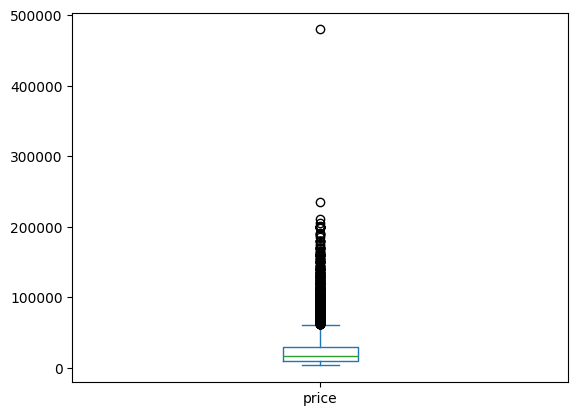

In [160]:
mobiles['price'].plot.box()

In [161]:
mobiles[mobiles['price']>100000]

,name,price,spec_score,user_rating,ram,battery,os,img,brand,screen_res,...,front_primary,expandable_upto,storage,5g,nfc,ir_blaster,cpu_name,cpu_brand,cpu_cores,cpu_speed
2,samsung galaxy s25 edge,109999.0,89.0,4.45,12.0,3900.0,android,https://cdn1.smartprix.com/rx-itijhjvfg-w280-h...,samsung,QHD+,...,12.0,0.0,256.0,1,1,0,snapdragon 8elite,snapdragon,8.0,4.47
10,samsung galaxy s25 ultra,129999.0,93.0,4.15,12.0,5000.0,android,https://cdn1.smartprix.com/rx-i3jzefawx-w280-h...,samsung,QHD+,...,12.0,0.0,256.0,1,1,0,snapdragon 8 elite,snapdragon,8.0,4.32
14,samsung galaxy s26 ultra,159990.0,83.0,4.45,12.0,5000.0,android,https://cdn1.smartprix.com/rx-irl2qxdwz-w280-h...,samsung,4K UHD,...,50.0,0.0,256.0,1,0,0,NaN,NaN,8.0,NaN
30,samsung galaxy s25 edge (12gb ram + 512gb),109999.0,89.0,4.10,12.0,3900.0,android,https://cdn1.smartprix.com/rx-itijhjvfg-w280-h...,samsung,QHD+,...,12.0,0.0,512.0,1,1,0,snapdragon 8elite,snapdragon,8.0,4.47
37,samsung galaxy z fold 7,169990.0,94.0,4.40,12.0,4400.0,android,https://cdn1.smartprix.com/rx-i8fmxk1ns-w280-h...,samsung,Ultra HD+,...,10.0,0.0,256.0,1,1,0,snapdragon 8 elite,snapdragon,8.0,4.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6109,vivo x fold plus,113990.0,91.0,4.20,12.0,4730.0,android,https://cdn1.smartprix.com/rx-ifi9x8tao-w280-h...,vivo,4K UHD,...,16.0,0.0,256.0,1,1,0,snapdragon 8+ gen1,snapdragon,8.0,3.20
6110,vivo x fold 2,107990.0,89.0,4.25,12.0,4800.0,android,https://cdn1.smartprix.com/rx-iofhj9oba-w280-h...,vivo,4K UHD,...,16.0,0.0,256.0,1,1,0,snapdragon 8 gen2,snapdragon,8.0,3.20
6128,vivo x fold 5g (12gb ram + 512gb),118990.0,91.0,4.55,12.0,4600.0,android,https://cdn1.smartprix.com/rx-ihoza0ksc-w280-h...,vivo,4K UHD,...,16.0,0.0,512.0,1,1,0,snapdragon 8 gen1,snapdragon,8.0,3.00
6772,lg slide,121990.0,90.0,4.70,8.0,4000.0,android,https://cdn1.smartprix.com/rx-id6rvb86y-w280-h...,lg,FHD+,...,32.0,2048.0,128.0,1,1,0,snapdragon 765g,snapdragon,8.0,2.40


<Axes: >

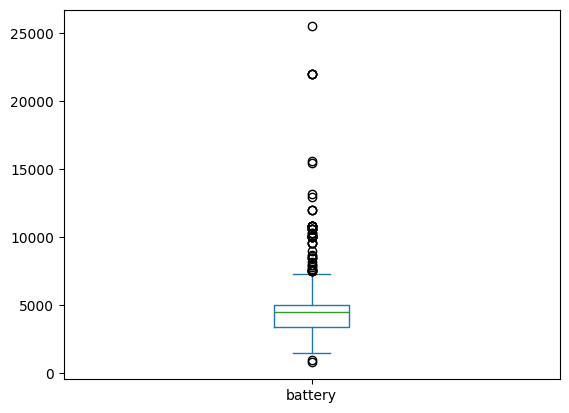

In [166]:
mobiles['battery'].plot.box()

In [170]:
mobiles = mobiles.drop(mobiles[mobiles['battery'] < 2000].index,axis=0).reset_index(drop=True)

In [171]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7166 entries, 0 to 7165
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   name                   7166 non-null   object  
 1   brand                  7166 non-null   object  
 2   os                     7166 non-null   category
 3   cpu_brand              6151 non-null   object  
 4   cpu_name               6367 non-null   object  
 5   cpu_cores              7109 non-null   float64 
 6   cpu_speed              6801 non-null   float64 
 7   5g                     7166 non-null   int8    
 8   nfc                    7166 non-null   int8    
 9   ir_blaster             7166 non-null   int8    
 10  ram                    7126 non-null   float64 
 11  storage                7156 non-null   float64 
 12  battery                7125 non-null   float64 
 13  screen_size            7162 non-null   float64 
 14  aspect_ratio_category  7144 non-null   c

In [164]:
mobiles.columns

Index(['name', 'price', 'spec_score', 'user_rating', 'ram', 'battery', 'os',
       'img', 'brand', 'screen_res', 'refresh_rate', 'screen_size',
       'aspect_ratio_category', 'ppi', 'rear_cameras', 'front_cameras',
       'rear_primary', 'front_primary', 'expandable_upto', 'storage', '5g',
       'nfc', 'ir_blaster', 'cpu_name', 'cpu_brand', 'cpu_cores', 'cpu_speed'],
      dtype='object')

In [165]:
mobiles = mobiles[[
    'name',
    'brand',
    'os',
    'cpu_brand',
    'cpu_name',
    'cpu_cores',
    'cpu_speed',
    '5g',
    'nfc',
    'ir_blaster',
    'ram',
    'storage',
    'battery',
    'screen_size',
    'aspect_ratio_category',
    'screen_res',
    'refresh_rate',
    'ppi',
    'rear_cameras',
    'rear_primary',
    'front_cameras',
    'front_primary',
    'expandable_upto',
    'spec_score',
    'user_rating',
    'price',
    'img'
]]

In [172]:
dbo = Database(database = 'project')
dbo.create_table(mobiles,'mobiles')
dbo.close()